# SARSA($\lambda$): assign TD errors with eligibility traces

SARSA($\lambda$) combines the on-policy TD error with a decaying trace:

$$\delta_t=R_{t+1}+\gamma(1-d_t)Q(S_{t+1},A_{t+1})-Q(S_t,A_t),$$
$$E_t(s,a)=\gamma\lambda E_{t-1}(s,a)+\mathbf 1\{s=S_t,a=A_t\},\qquad Q\leftarrow Q+\alpha\delta_tE_t.$$

Here $E_t$ is the eligibility trace, $\lambda$ its decay parameter, $\alpha$ the learning rate, $\gamma$ the discount factor, and $d_t$ the terminal indicator. A large $\lambda$ spreads each TD error farther backward.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

ENV_ID = "FrozenLake-v1"
TOTAL_TIMESTEPS = 5_000
LEARNING_RATE = 0.2
GAMMA = 0.99
TRACE_DECAY = 0.9
EPSILON_START = 1.0
EPSILON_END = 0.05
EXPLORATION_STEPS = 3_000
SEED = 7

env = gym.make(ENV_ID, is_slippery=False)
rng = np.random.default_rng(SEED)
q_table = np.zeros((env.observation_space.n, env.action_space.n))
eligibility = np.zeros_like(q_table)

## 1. Use an epsilon-greedy on-policy behavior

SARSA bootstraps from the next action actually selected by this behavior policy. Deterministic evaluation uses only the greedy branch.

In [2]:
def epsilon_at(step):
    fraction = min(step / EXPLORATION_STEPS, 1.0)
    return EPSILON_START + fraction * (EPSILON_END - EPSILON_START)


def select_action(state, step, deterministic=False):
    if not deterministic and rng.random() < epsilon_at(step):
        return int(rng.integers(q_table.shape[1]))
    return int(np.argmax(q_table[state]))

## 2. Update every traced state-action pair

Accumulating traces add one at the current pair, then all entries receive the TD error. `terminated` removes the bootstrap; `truncated` keeps it but still resets traces at the episode boundary.

In [3]:
def train(total_timesteps):
    episode_returns = []
    episode_return = 0.0
    state, _ = env.reset(seed=SEED)
    action = select_action(state, 0)

    for step in range(total_timesteps):
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_action = select_action(next_state, step + 1)
        target = reward + GAMMA * (1 - terminated) * q_table[next_state, next_action]
        td_error = target - q_table[state, action]

        eligibility[:] *= GAMMA * TRACE_DECAY
        eligibility[state, action] += 1
        q_table[:] += LEARNING_RATE * td_error * eligibility
        episode_return += reward

        if terminated or truncated:
            episode_returns.append(episode_return)
            episode_return = 0.0
            eligibility.fill(0.0)
            state, _ = env.reset()
            action = select_action(state, step + 1)
        else:
            state, action = next_state, next_action
    return episode_returns


episode_returns = train(TOTAL_TIMESTEPS)
env.close()

## 3. Plot learning

The moving average estimates the recent success rate while retaining individual binary returns.

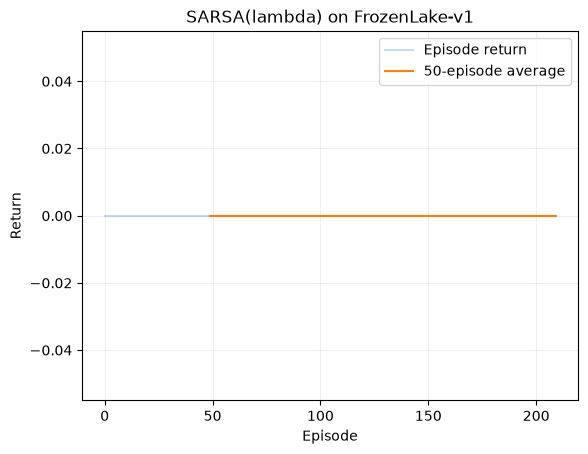

In [4]:
window = min(50, len(episode_returns))
moving_average = np.convolve(episode_returns, np.ones(window) / window, mode="valid")
plt.plot(episode_returns, alpha=0.25, label="Episode return")
plt.plot(np.arange(window - 1, len(episode_returns)), moving_average, label=f"{window}-episode average")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("SARSA(lambda) on FrozenLake-v1")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 4. Evaluate the greedy policy

This opens a separate rendered environment and disables exploration for 5 episodes.

In [5]:
evaluation_env = gym.make(ENV_ID, render_mode="human", is_slippery=False)
evaluation_returns = []
try:
    for episode in range(5):
        state, _ = evaluation_env.reset(seed=10 + episode)
        total_reward = 0.0
        done = False
        while not done:
            action = select_action(state, TOTAL_TIMESTEPS, deterministic=True)
            state, reward, terminated, truncated, _ = evaluation_env.step(action)
            total_reward += reward
            done = terminated or truncated
        evaluation_returns.append(total_reward)
finally:
    evaluation_env.close()
print("Episode returns:", evaluation_returns)

Episode returns: [0.0, 0.0, 0.0, 0.0, 0.0]
